In [305]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np

file_path = "embedded_system_network_security_dataset.csv"
eps = 1e-6

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ziya07/network-traffic-anomaly-detection-dataset",
  file_path,
)

df.head()

/var/folders/qh/42bwc8q10_72vdyvdlgw7xvc0000gn/T/ipykernel_68826/4064539874.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [306]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   packet_size            1000 non-null   float64
 1   inter_arrival_time     1000 non-null   float64
 2   src_port               1000 non-null   int64  
 3   dst_port               1000 non-null   int64  
 4   packet_count_5s        1000 non-null   float64
 5   mean_packet_size       1000 non-null   float64
 6   spectral_entropy       1000 non-null   float64
 7   frequency_band_energy  1000 non-null   float64
 8   label                  1000 non-null   float64
 9   protocol_type_TCP      1000 non-null   bool   
 10  protocol_type_UDP      1000 non-null   bool   
 11  src_ip_192.168.1.2     1000 non-null   bool   
 12  src_ip_192.168.1.3     1000 non-null   bool   
 13  dst_ip_192.168.1.5     1000 non-null   bool   
 14  dst_ip_192.168.1.6     1000 non-null   bool   
 15  tcp_flags_FIN   

In [307]:
df.describe()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000,1000.000000,1000.00000
mean,0.502446,0.512259,32024.617000,199.769000,0.506857,0.0,0.495222,0.485651,0.10000
std,0.289606,0.281130,18520.890349,180.078488,0.303271,0.0,0.292927,0.295953,0.30015
min,0.000000,0.000000,1038.000000,53.000000,0.000000,0.0,0.000000,0.000000,0.00000
25%,0.256263,0.275909,16245.250000,53.000000,0.267857,0.0,0.236912,0.228039,0.00000
50%,0.499642,0.515971,31883.000000,80.000000,0.500000,0.0,0.504290,0.467905,0.00000
75%,0.741410,0.746523,47746.250000,443.000000,0.785714,0.0,0.761556,0.750876,0.00000
max,1.000000,1.000000,65484.000000,443.000000,1.000000,0.0,1.000000,1.000000,1.00000


In [309]:
df.corr(numeric_only=True)

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
packet_size,1.000000,0.005373,0.027990,-0.034396,0.038993,NaN,0.008227,-0.054754,-0.001646,0.059896,-0.079848,0.017640,-0.009216,0.014047,-0.023226,0.002092,0.025689,-0.019397
inter_arrival_time,0.005373,1.000000,0.063737,0.011177,-0.009365,NaN,-0.002732,-0.054100,-0.045855,0.050535,0.000806,-0.006566,-0.008948,0.004755,-0.020440,-0.014196,0.025790,-0.006993
src_port,0.027990,0.063737,1.000000,0.002580,0.056714,NaN,-0.079819,-0.050363,-0.009721,-0.010335,0.017877,-0.019101,-0.016674,0.010046,-0.004376,0.002692,0.036509,-0.036042
dst_port,-0.034396,0.011177,0.002580,1.000000,-0.043207,NaN,-0.004237,0.027158,-0.022685,0.005435,-0.019111,0.023961,-0.041049,-0.047746,0.009846,-0.019746,0.005979,0.001477
packet_count_5s,0.038993,-0.009365,0.056714,-0.043207,1.000000,NaN,-0.008785,-0.027753,-0.113581,-0.010617,-0.061596,0.055077,-0.054025,-0.015131,0.013438,-0.016900,0.003579,0.039748
mean_packet_size,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spectral_entropy,0.008227,-0.002732,-0.079819,-0.004237,-0.008785,NaN,1.000000,0.043702,-0.019469,-0.031270,-0.061794,-0.004495,-0.018537,0.021850,-0.036401,0.043942,0.030400,-0.027847
frequency_band_energy,-0.054754,-0.054100,-0.050363,0.027158,-0.027753,NaN,0.043702,1.000000,-0.025252,0.013681,-0.012977,-0.036501,0.027598,-0.008618,-0.008993,-0.015318,-0.011618,-0.029721
label,-0.001646,-0.045855,-0.009721,-0.022685,-0.113581,NaN,-0.019469,-0.025252,1.000000,0.006481,-0.024381,-0.047321,0.029597,0.023271,0.004915,-0.016144,-0.035377,0.019119
protocol_type_TCP,0.059896,0.050535,-0.010335,0.005435,-0.010617,NaN,-0.031270,0.013681,0.006481,1.000000,-0.498431,0.017304,0.026863,-0.008258,-0.030367,0.039555,-0.020813,0.028226


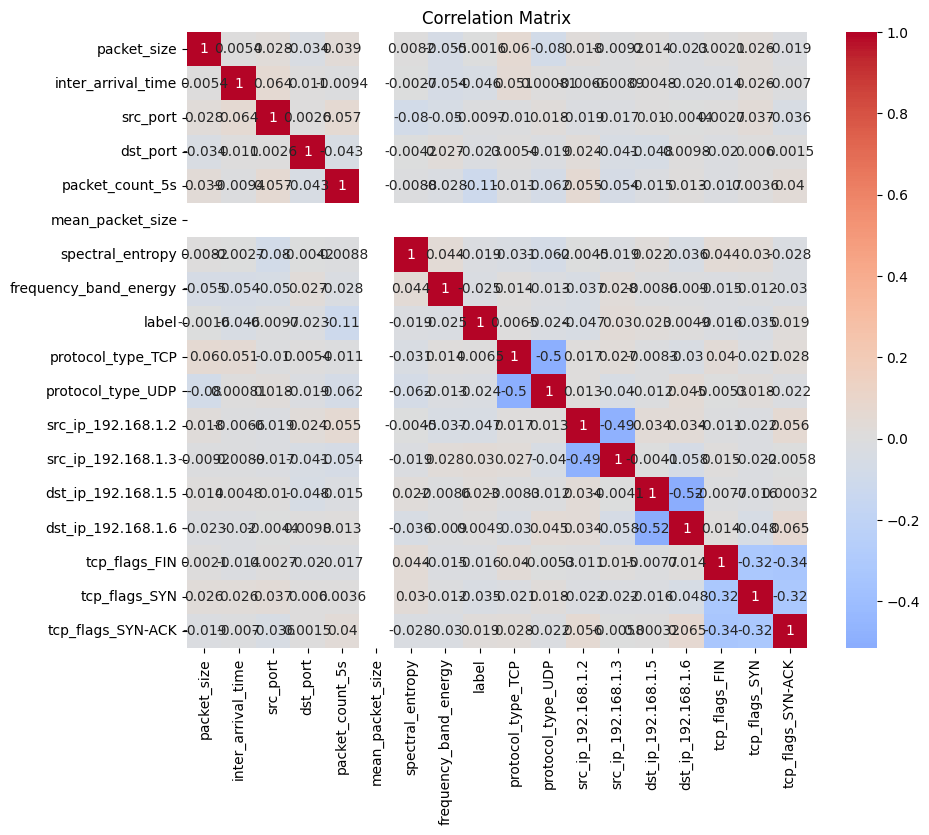

In [310]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [312]:
corr = df.corr(numeric_only=True)

corr["label"].sort_values(ascending=False)

label                    1.000000
src_ip_192.168.1.3       0.029597
dst_ip_192.168.1.5       0.023271
tcp_flags_SYN-ACK        0.019119
protocol_type_TCP        0.006481
dst_ip_192.168.1.6       0.004915
packet_size             -0.001646
src_port                -0.009721
tcp_flags_FIN           -0.016144
spectral_entropy        -0.019469
dst_port                -0.022685
protocol_type_UDP       -0.024381
frequency_band_energy   -0.025252
tcp_flags_SYN           -0.035377
inter_arrival_time      -0.045855
src_ip_192.168.1.2      -0.047321
packet_count_5s         -0.113581
mean_packet_size              NaN
Name: label, dtype: float64

In [314]:
df["label"].value_counts()
df["label"].value_counts(normalize=True)

label
0.0    0.9
1.0    0.1
Name: proportion, dtype: float64

In [316]:
df.head(5)

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


# Обучаем

In [317]:
X = df.drop(columns=["label"])
y = df["label"].values

In [318]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [319]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [329]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=5)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.90      0.98      0.94       180
         1.0       0.20      0.05      0.08        20

    accuracy                           0.89       200
   macro avg       0.55      0.51      0.51       200
weighted avg       0.83      0.89      0.85       200



In [342]:
import joblib

joblib.dump(rf, "./../ml-service/models/v0/model.joblib")
joblib.dump(scaler, "./../ml-service/models/v0/scaler.joblib")

['./../ml-service/models/v0/scaler.joblib']